In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel
import pingouin

/home/avirinchipur/.local/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


In [2]:
expert1_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/Item_level_scores_Katarina.csv'
expert2_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/Item_level_scores_Veerle.csv'
self_report_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/self_report_unified.csv'
gpt4_file = '/cronus_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/expt_gpt-4-1106-preview.dep_list_phq9items_score_classify2_editted_unified.csv'
gpt5_file = '/chronos_data/avirinchipur/reasoning_for_psych/expts/parsed_responses/expt_gpt-5.dep_list_phq9items_score_classify2.csv'

In [3]:
expert1_df = pd.read_csv(expert1_file)
expert2_df = pd.read_csv(expert2_file)
self_report_df = pd.read_csv(self_report_file)
gpt4_df = pd.read_csv(gpt4_file)
gpt5_df = pd.read_csv(gpt5_file)

In [4]:
gpt5_df.columns

Index(['user_id', 'user_text', 'score_Depressed_Mood', 'spans_Depressed_Mood',
       'isInferred_Depressed_Mood', 'score_Anhedonia', 'spans_Anhedonia',
       'isInferred_Anhedonia', 'score_Insomnia_or_Hypersomnia',
       'spans_Insomnia_or_Hypersomnia', 'isInferred_Insomnia_or_Hypersomnia',
       'score_Fatigue', 'spans_Fatigue', 'isInferred_Fatigue',
       'score_Poor_appetite_or_overeating',
       'spans_Poor_appetite_or_overeating',
       'isInferred_Poor_appetite_or_overeating',
       'score_Worthlessness_or_Guilt', 'spans_Worthlessness_or_Guilt',
       'isInferred_Worthlessness_or_Guilt', 'score_Difficulty_concentrating',
       'spans_Difficulty_concentrating', 'isInferred_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation',
       'spans_Psychomotor_agitation_or_retardation',
       'isInferred_Psychomotor_agitation_or_retardation',
       'score_Suicidal_ideation', 'spans_Suicidal_ideation',
       'isInferred_Suicidal_ideation'],
      dtype

In [5]:
gpt4_df.columns

Index(['user_id', 'user_text', 'score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation',
       'spans_Anhedonia', 'spans_Depressed_Mood',
       'spans_Insomnia_or_Hypersomnia', 'spans_Fatigue',
       'spans_Poor_appetite_or_overeating', 'spans_Worthlessness_or_Guilt',
       'spans_Difficulty_concentrating',
       'spans_Psychomotor_agitation_or_retardation', 'spans_Suicidal_ideation',
       'isInferred_Anhedonia', 'isInferred_Depressed_Mood',
       'isInferred_Insomnia_or_Hypersomnia', 'isInferred_Fatigue',
       'isInferred_Poor_appetite_or_overeating',
       'isInferred_Worthlessness_or_Guilt',
       'isInferred_Difficulty_concentrating',
       'isInferred_Psychomotor_agitation_or_retardation',
       'isInferred_Suicidal_ideation'],
    

In [6]:
score_columns = ['score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

In [7]:
for col in score_columns:
    span_column_name = col.replace('score_', 'spans_')
    print (span_column_name, gpt5_df[span_column_name].isna().sum())

spans_Anhedonia 0
spans_Depressed_Mood 0
spans_Insomnia_or_Hypersomnia 0
spans_Fatigue 0
spans_Poor_appetite_or_overeating 0
spans_Worthlessness_or_Guilt 0
spans_Difficulty_concentrating 0
spans_Psychomotor_agitation_or_retardation 0
spans_Suicidal_ideation 0


In [8]:
expert1_df = expert1_df.fillna(0)
expert2_df = expert2_df.fillna(0)

## Correlations

In [30]:
gpt5_expert1_item_corr = []
for col_name in score_columns:
    temp = pd.merge(expert1_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_expert1', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    expert_scores, gpt5_scores = temp[col_name+'_expert1'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
    gpt5_expert1_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(expert_scores)))
pd.DataFrame(gpt5_expert1_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.69,0.0,209
1,score_Depressed_Mood,0.81,0.0,209
2,score_Insomnia_or_Hypersomnia,0.55,0.0,209
3,score_Fatigue,0.67,0.0,209
4,score_Poor_appetite_or_overeating,0.39,0.0,209
5,score_Worthlessness_or_Guilt,0.66,0.0,209
6,score_Difficulty_concentrating,0.36,0.0,209
7,score_Psychomotor_agitation_or_retardation,0.24,0.0,209
8,score_Suicidal_ideation,0.70,0.0,209


In [31]:
gpt5_expert2_item_corr = []
for col_name in score_columns:
    temp = pd.merge(expert2_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_expert1', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    expert_scores, gpt5_scores = temp[col_name+'_expert1'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
    gpt5_expert2_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(expert_scores)))
pd.DataFrame(gpt5_expert2_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.73,0.0,209
1,score_Depressed_Mood,0.84,0.0,209
2,score_Insomnia_or_Hypersomnia,0.63,0.0,209
3,score_Fatigue,0.65,0.0,209
4,score_Poor_appetite_or_overeating,0.50,0.0,209
5,score_Worthlessness_or_Guilt,0.62,0.0,209
6,score_Difficulty_concentrating,0.50,0.0,209
7,score_Psychomotor_agitation_or_retardation,0.27,0.0,209
8,score_Suicidal_ideation,0.62,0.0,209


In [32]:
# Correlate self-report with gpt4 only for expert annotated user_ids
gpt5_self_report_item_corr = []
for col_name in score_columns:
    temp = pd.merge(self_report_df[['user_id', col_name]], gpt5_df[['user_id', col_name]], on='user_id', suffixes=('_self_report', '_gpt5'))
    temp = temp[temp.isna().sum(1)==0]
    temp = temp[temp.user_id.isin(expert1_df.user_id)]
    self_report_scores, gpt5_scores = temp[col_name+'_self_report'], temp[col_name+'_gpt5']
    pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
    gpt5_self_report_item_corr.append((col_name, round(pearson_score, 2), round(p_val, 3), len(self_report_scores)))
pd.DataFrame(gpt5_self_report_item_corr, columns=['item', 'pearson_score', 'p_val', 'n'])

,item,pearson_score,p_val,n
0,score_Anhedonia,0.57,0.000,209
1,score_Depressed_Mood,0.68,0.000,209
2,score_Insomnia_or_Hypersomnia,0.46,0.000,209
3,score_Fatigue,0.47,0.000,209
4,score_Poor_appetite_or_overeating,0.33,0.000,209
5,score_Worthlessness_or_Guilt,0.40,0.000,209
6,score_Difficulty_concentrating,0.33,0.000,209
7,score_Psychomotor_agitation_or_retardation,0.14,0.042,209
8,score_Suicidal_ideation,0.25,0.000,209


In [47]:
# Correlate the phq9 scores between expert1 and gpt4
gpt5_phq9 = gpt4_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt4_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
expert1_phq9 = expert1_df[score_columns].sum(1)
expert1_phq9 = pd.concat([expert1_df['user_id'], expert1_phq9], axis=1).rename(columns={0: 'phq9_expert1'})
temp = pd.merge(gpt5_phq9, expert1_phq9, on='user_id', suffixes=('_gpt5', '_expert1'))
temp = temp[temp.isna().sum(1)==0]
expert_scores, gpt5_scores = temp['phq9_expert1'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
print ("Pearson Correlation between expert1 and gpt4 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))


Pearson Correlation between expert1 and gpt4 phq9 scores: 0.796 (p=0.0)


In [46]:
# Correlate the phq9 scores between expert2 and gpt4 
gpt5_phq9 = gpt5_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt5_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
expert2_phq9 = expert2_df[score_columns].sum(1)
expert2_phq9 = pd.concat([expert2_df['user_id'], expert2_phq9], axis=1).rename(columns={0: 'phq9_expert2'})
temp = pd.merge(gpt5_phq9, expert2_phq9, on='user_id', suffixes=('_gpt5', '_expert2'))
temp = temp[temp.isna().sum(1)==0]
expert_scores, gpt5_scores = temp['phq9_expert2'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(expert_scores, gpt5_scores)
print ("Pearson Correlation between expert2 and gpt5 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between expert2 and gpt5 phq9 scores: 0.82 (p=0.0)


In [ ]:
# Correlate self report and gpt4
self_report_phq9 = self_report_df[score_columns].sum(1)
self_report_phq9 = pd.concat([self_report_df['user_id'], self_report_phq9], axis=1).rename(columns={0: 'phq9_self_report'})
gpt5_phq9 = gpt5_df[score_columns].sum(1)
gpt5_phq9 = pd.concat([gpt5_df['user_id'], gpt5_phq9], axis=1).rename(columns={0: 'phq9_gpt5'})
temp = pd.merge(self_report_phq9, gpt5_phq9, on='user_id', suffixes=('_self_report', '_gpt5'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, gpt5_scores = temp['phq9_self_report'], temp['phq9_gpt5']
pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
print ("Pearson Correlation between self report and gpt5 phq9 scores: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between self report and gpt5 phq9 scores: 0.678 (p=0.0)


In [44]:
# Correlate self report and gpt4 only for the expert annotated user_ids
temp2 = temp[temp.user_id.isin(expert1_df.user_id)]
self_report_scores, gpt5_scores = temp2['phq9_self_report'], temp2['phq9_gpt5']
pearson_score, p_val = pearsonr(self_report_scores, gpt5_scores)
print ("Pearson Correlation between self report and gpt5 phq9 scores for expert annotated user_ids: {} (p={})".format(round(pearson_score, 3), round(p_val, 3)))

Pearson Correlation between self report and gpt5 phq9 scores for expert annotated user_ids: 0.679 (p=0.0)


In [45]:
# Correlate expert1 with self report and expert2 with self report 
self_report_phq9 = self_report_df[score_columns].sum(1)
self_report_phq9 = pd.concat([self_report_df['user_id'], self_report_phq9], axis=1).rename(columns={0: 'phq9_self_report'})
expert1_phq9 = expert1_df[score_columns].sum(1)
expert1_phq9 = pd.concat([expert1_df['user_id'], expert1_phq9], axis=1).rename(columns={0: 'phq9_expert1'})
expert2_phq9 = expert2_df[score_columns].sum(1)
expert2_phq9 = pd.concat([expert2_df['user_id'], expert2_phq9], axis=1).rename(columns={0: 'phq9_expert2'})

temp = pd.merge(self_report_phq9, expert1_phq9, on='user_id', suffixes=('_self_report', '_expert1'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, expert1_scores = temp['phq9_self_report'], temp['phq9_expert1']
pearson_score, p_val = pearsonr(self_report_scores, expert1_scores)
print ("Pearson Correlation between self report and expert1 phq9 scores: {} (p={})".format(round(pearson_score, 5), round(p_val, 3)))

temp = pd.merge(self_report_phq9, expert2_phq9, on='user_id', suffixes=('_self_report', '_expert2'))
temp = temp[temp.isna().sum(1)==0]
self_report_scores, expert2_scores = temp['phq9_self_report'], temp['phq9_expert2']
pearson_score, p_val = pearsonr(self_report_scores, expert2_scores)
print ("Pearson Correlation between self report and expert2 phq9 scores: {} (p={})".format(round(pearson_score, 5), round(p_val, 3)))

Pearson Correlation between self report and expert1 phq9 scores: 0.68073 (p=0.0)
Pearson Correlation between self report and expert2 phq9 scores: 0.68102 (p=0.0)


## Distribution

In [9]:
from matplotlib import font_manager
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
bold_font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf'
italics_font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf'
# Create a font properties object
custom_font = font_manager.FontProperties(fname=font_path)
custom_font_bold = font_manager.FontProperties(fname=bold_font_path)
custom_font_italics = font_manager.FontProperties(fname=italics_font_path)

In [10]:
from matplotlib.colorbar import ColorbarBase
from matplotlib import gridspec
import matplotlib.colors

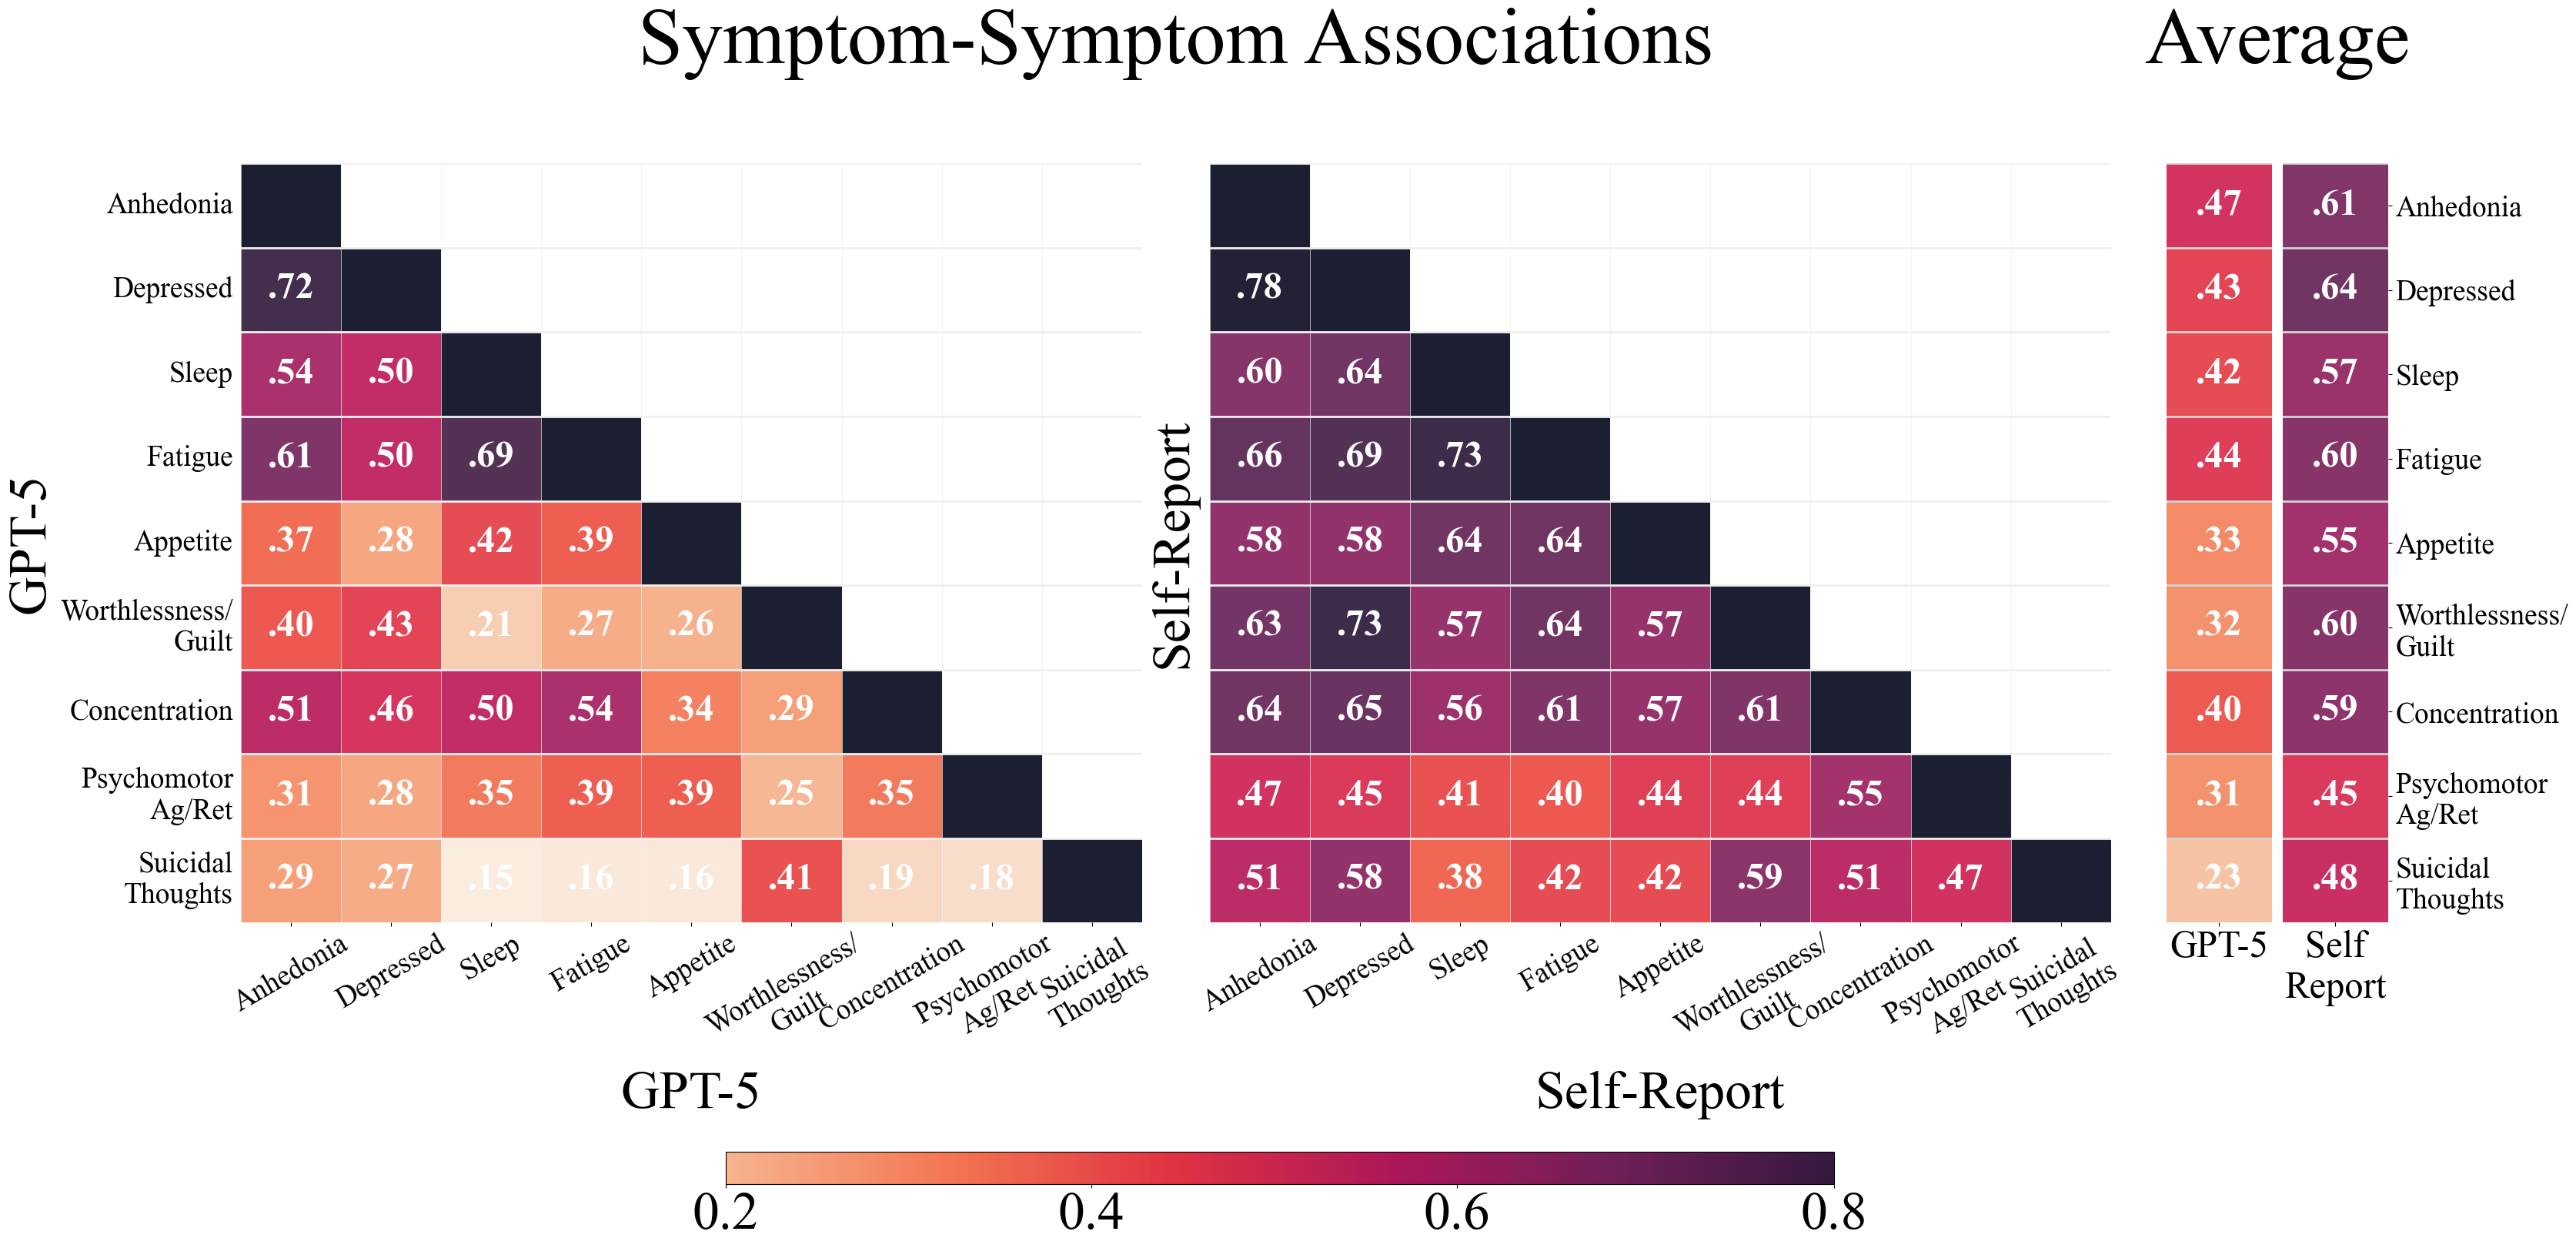

In [11]:
# Make gridspec such that there are two parts to the figure, 
# one which will be split into subplots for correlation matrix 
# and the other will be for the average
# The former will have more wspace between the heatmaps and the latter will have less wspace

f = plt.figure(figsize=(36, 17))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.80, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.075)
gs2 = gridspec.GridSpec(1, 2, figure=f, left=0.82, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.1)
gs3 = gridspec.GridSpec(1, 1, figure=f, top=0.125, bottom=0.1, left=0.3, right=0.7, hspace=0.1)

# put gpt4 corr map in a0 and self report corr map in a1
# put gpt4 avg in a2 and self report avg in a3
a0 = f.add_subplot(gs1[0])
a1 = f.add_subplot(gs1[1])
a2 = f.add_subplot(gs2[0])
a3 = f.add_subplot(gs2[1])
a4 = f.add_subplot(gs3[0])

# Correlation in between all the items 
corr_df = gpt5_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = gpt5_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''
# Turn this into sns heatmap, with x axis label rotated 35 degrees, font size of the correlation values inside the heatmap as 20

# corrs_trials = []
# for trial in range(10):
#     # sample shape[0] users with replacement
#     sample = gpt4_df.sample(n=gpt4_df.shape[0], replace=True)
#     # calculate the correlation matrix
#     corr_df = sample[[i for i in score_columns]].corr().values.round(2)
#     # append to corrs_trials
#     corrs_trials.append(corr_df)

# # create a 3D array of the correlation matrices
# corrs_trials = np.array(corrs_trials)
# # sort along the trials axis and take the 2.5th and 97.5th percentiles
# lower_bound = np.percentile(corrs_trials, 2.5, axis=0)
# upper_bound = np.percentile(corrs_trials, 97.5, axis=0)

# # annotate the corr_df_annot with [lower_bound, upper_bound] below the correlation values in smaller font
# conf_bounds_annot = corr_df_annot.copy()
# for idx in range(9):
#     for jdx in range(9):
#         if idx != jdx:
#             conf_bounds_annot.iloc[idx, jdx] = '['+f'{lower_bound[idx, jdx]:.2f}'[-3:]+','+ f'{upper_bound[idx, jdx]:.2f}]'[-4:]

mask = np.zeros_like(corr_df, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

# f, (a0, a1, a2, a3) = plt.subplots(1, 4, figsize=(36, 15), gridspec_kw={'width_ratios': [3, 3, 0.35, 0.35], 'wspace': 0.1})

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a0, cbar=False)

# # Add custom annotations
# for i in range(corr_df.shape[0]):
#     for j in range(corr_df.shape[1]):
#         if not mask[i, j]:
#             corr_text = corr_df_annot.iloc[i, j]
#             conf_bounds = conf_bounds_annot.iloc[i, j]
            
#             a0.text(j + 0.5, i + 0.5, corr_text, ha='center', va='center',
#                     fontsize=30, fontweight='bold', color='white', fontproperties=custom_font_bold)
#             a0.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
#                     fontsize=18, color='white', fontproperties=custom_font)


a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)


tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']

a0.set_xticklabels(tick_labels, rotation=30, fontsize=27, fontproperties=custom_font)
a0.set_yticklabels(tick_labels_y, rotation=0, fontsize=27,  fontproperties=custom_font)
a0.set_xlabel('GPT-5', fontsize=50, fontproperties=custom_font)
a0.set_ylabel('GPT-5', fontsize=50, fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='', ax=a2, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a2.axhline(i, color='lightgray', lw=2)

a2.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a2.yaxis.tick_right()
a2.tick_params(right=False, bottom=True, left=False)
a2.set_xticklabels(['GPT-5'], rotation=0, fontsize=35,  fontproperties=custom_font)

###########################
###########################

# Correlation in between all the items 
corr_df = self_report_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = self_report_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a1, cbar=False)

a1.tick_params(left=False, bottom=True)

for i in range(9):
    a1.axhline(i, color='#f0f0f0', lw=2)
    a1.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
# a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nThoughts']

a1.set_xticklabels(tick_labels, rotation=30, fontsize=27, fontproperties=custom_font)
a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.set_xlabel('Self-Report', fontsize=50, fontproperties=custom_font)
a1.set_ylabel('Self-Report', fontsize=50, fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.15, vmax=0.8, alpha=0.9, fmt='', ax=a3, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a3.axhline(i, color='lightgray', lw=2)

a3.set_yticklabels(tick_labels_y, rotation=0, fontsize=27,  fontproperties=custom_font)
a3.yaxis.tick_right()
a3.tick_params(right=True, bottom=True, left=False)
a3.set_xticklabels(['Self\nReport'], rotation=0, fontsize=35,  fontproperties=custom_font)

###########################
###########################

rocket_r_colors = sns.color_palette("rocket_r").as_hex()
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", rocket_r_colors)

# Add colorbar to a4
cb1 = ColorbarBase(a4, cmap=my_cmap, orientation='horizontal', alpha=0.9)
# set 4 x ticks
cb1.set_ticks([0.0, 0.33, 0.66, 1.0])
a4.set_xticklabels([0.2, 0.4, 0.6, 0.8], fontsize=50, fontproperties=custom_font)

###########################
###########################

# Add ghost axes and titles on gs1 and gs2
ax_left = f.add_subplot(gs1[:])
ax_left.axis('off')
ax_left.set_title('Symptom-Symptom Associations\n', fontsize=75, fontproperties=custom_font)

ax_right = f.add_subplot(gs2[:])
ax_right.axis('off')
ax_right.set_title('Average\n', fontsize=75, fontproperties=custom_font)

plt.savefig('../data/figures/InterSymptomrelationship2GPT5.pdf', dpi=1040, bbox_inches='tight', format='pdf')

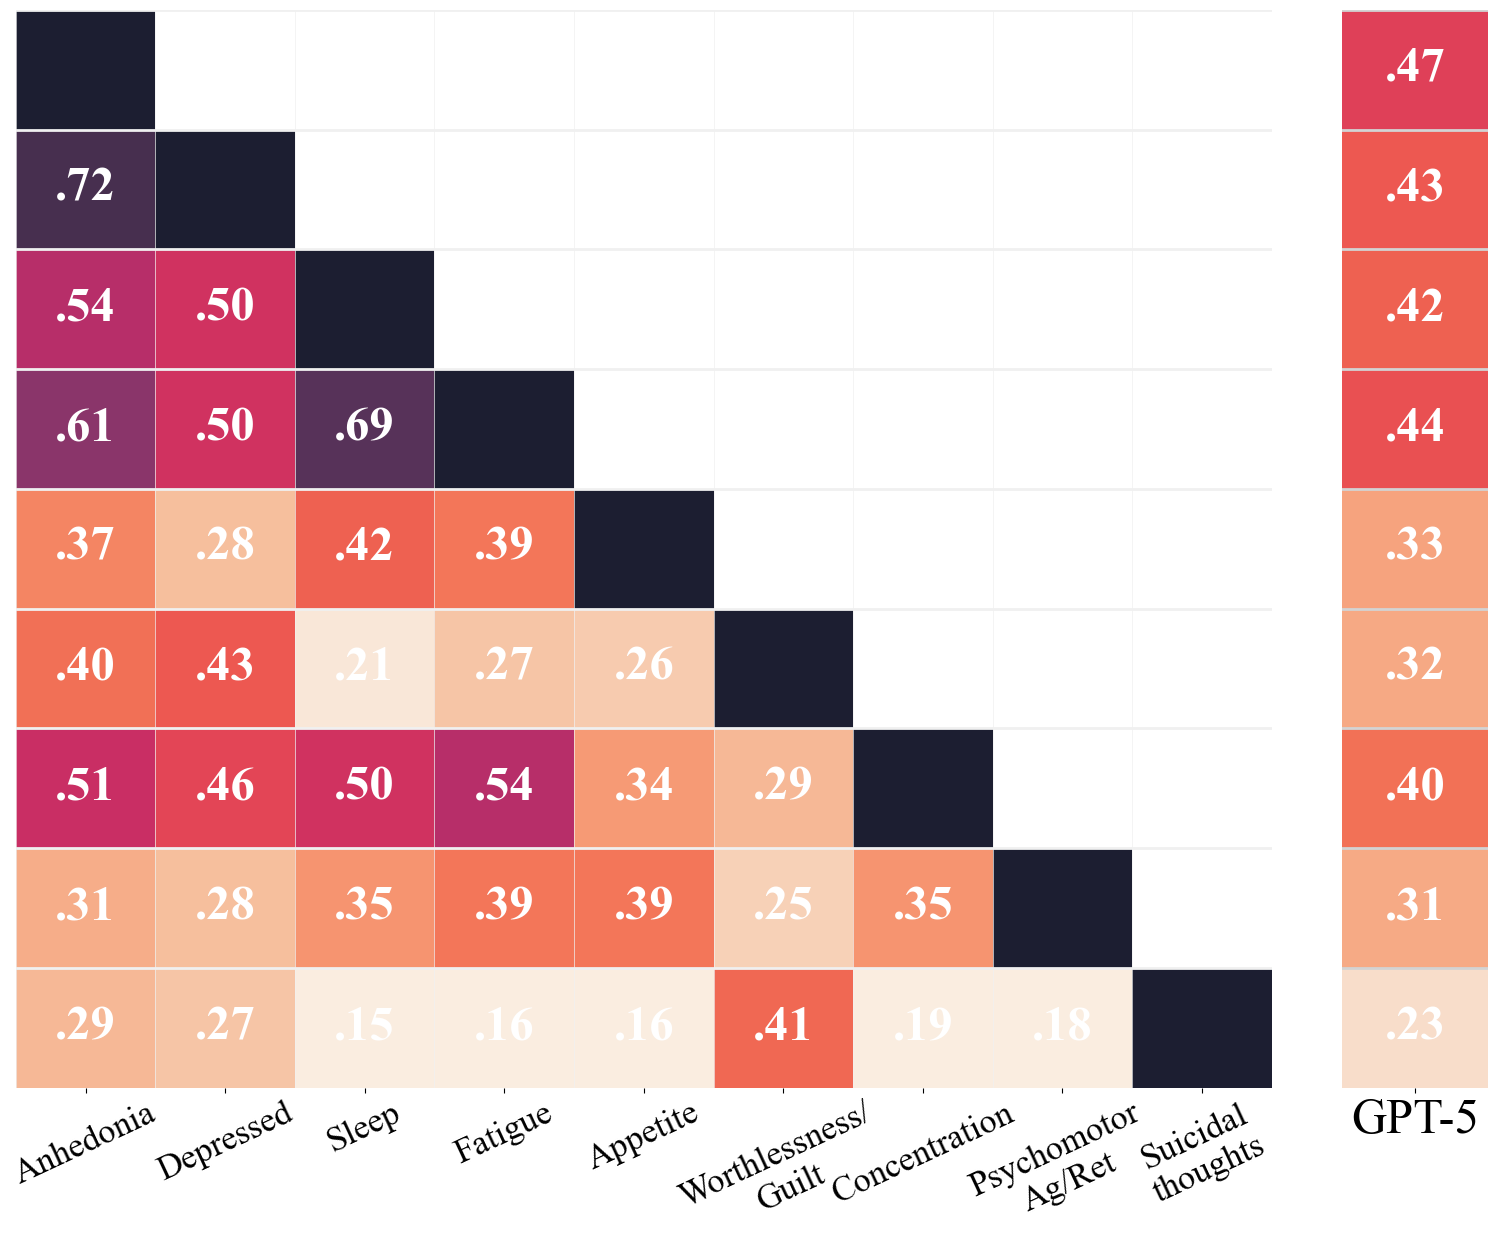

In [36]:
# Correlation in between all the items 
corr_df = gpt5_df[[i for i in score_columns]].corr().values.round(2)
corr_df_annot = gpt5_df[[i for i in score_columns]].corr().apply(lambda col: [f'{v:.2f}'[-3:] for v in col], axis=0)
for i in range(9): corr_df_annot.iloc[i, i] = ''
# Turn this into sns heatmap, with x axis label rotated 35 degrees, font size of the correlation values inside the heatmap as 20

f, (a0, a1) = plt.subplots(1, 2, figsize=(19, 14), gridspec_kw={'width_ratios': [3, 0.35], 'wspace': 0.1})

mask = np.zeros_like(corr_df, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

sns.heatmap(corr_df, annot = corr_df_annot, mask=mask, cmap='rocket_r', vmin=0.2, vmax=0.8, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'}, 
            ax=a0, cbar=False)

a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
# a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']

a0.set_xticklabels(tick_labels, rotation=25, fontsize=25, fontproperties=custom_font)
a0.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)

avgs = ((corr_df.sum(axis=1)-1.0)/8).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:]] for row in avgs for v in row]
sns.heatmap(avgs, annot=avgs_annot, cmap='rocket_r', vmin=0.2, vmax=0.8, alpha=0.9, fmt='', ax=a1, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'white'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=False)

for i in range(9):
    a1.axhline(i, color='lightgray', lw=2)
# a1.axhline(7, color='white', lw=6)

a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.yaxis.tick_right()
a1.tick_params(right=False, bottom=True, left=False)
a1.set_xticklabels(['GPT-5'], rotation=0, fontsize=35,  fontproperties=custom_font)

# cbar = a1.collections[0].colorbar
# # Apply font properties to the colorbar's tick labels
# for label in cbar.ax.get_yticklabels():
#     label.set_fontproperties(custom_font)
# # here set the labelsize by 20
# cbar.ax.tick_params(labelsize=40)

# plt.savefig('../data/figures/gpt4_item_corr_triu.png', dpi=1040, bbox_inches='tight')
# plt.savefig('../data/figures/gpt4_item_corr_triu.svg', dpi=2080, bbox_inches='tight')
plt.show()


In [38]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as clr

In [39]:
# clrs = list(map(lambda x: (x[0]/10.0, x[1]), enumerate(['#8e0152','#c51b7d','#de77ae','#f1b6da','#fde0ef','#f7f7f7','#e6f5d0','#b8e186','#7fbc41','#4d9221','#276419'])))
clrs = list(map(lambda x: (x[0]/10.0, x[1]), enumerate(['#40004b','#762a83','#9970ab','#c2a5cf','#e7d4e8','#f7f7f7','#d9f0d3','#a6dba0','#5aae61','#1b7837','#00441b'])))
# clrs = list(map(lambda x: (x[0]/6.0, x[1]), enumerate(['#5a77d1', '#6788ee', '#9abbff', '#a9aaab', '#f7a889', '#e26952', '#c95a44'])))

# clrs = list(map(lambda x: (x[0]/7.0, x[1]), enumerate(['#5a77d1', '#9abbff', '#c9d7f0', '#aeb9cf', '#edd1c2', '#f7a889', '#e26952', '#c95a44'])))

custom_cmap = clr.LinearSegmentedColormap.from_list('custom coolwarm', clrs, N=256)

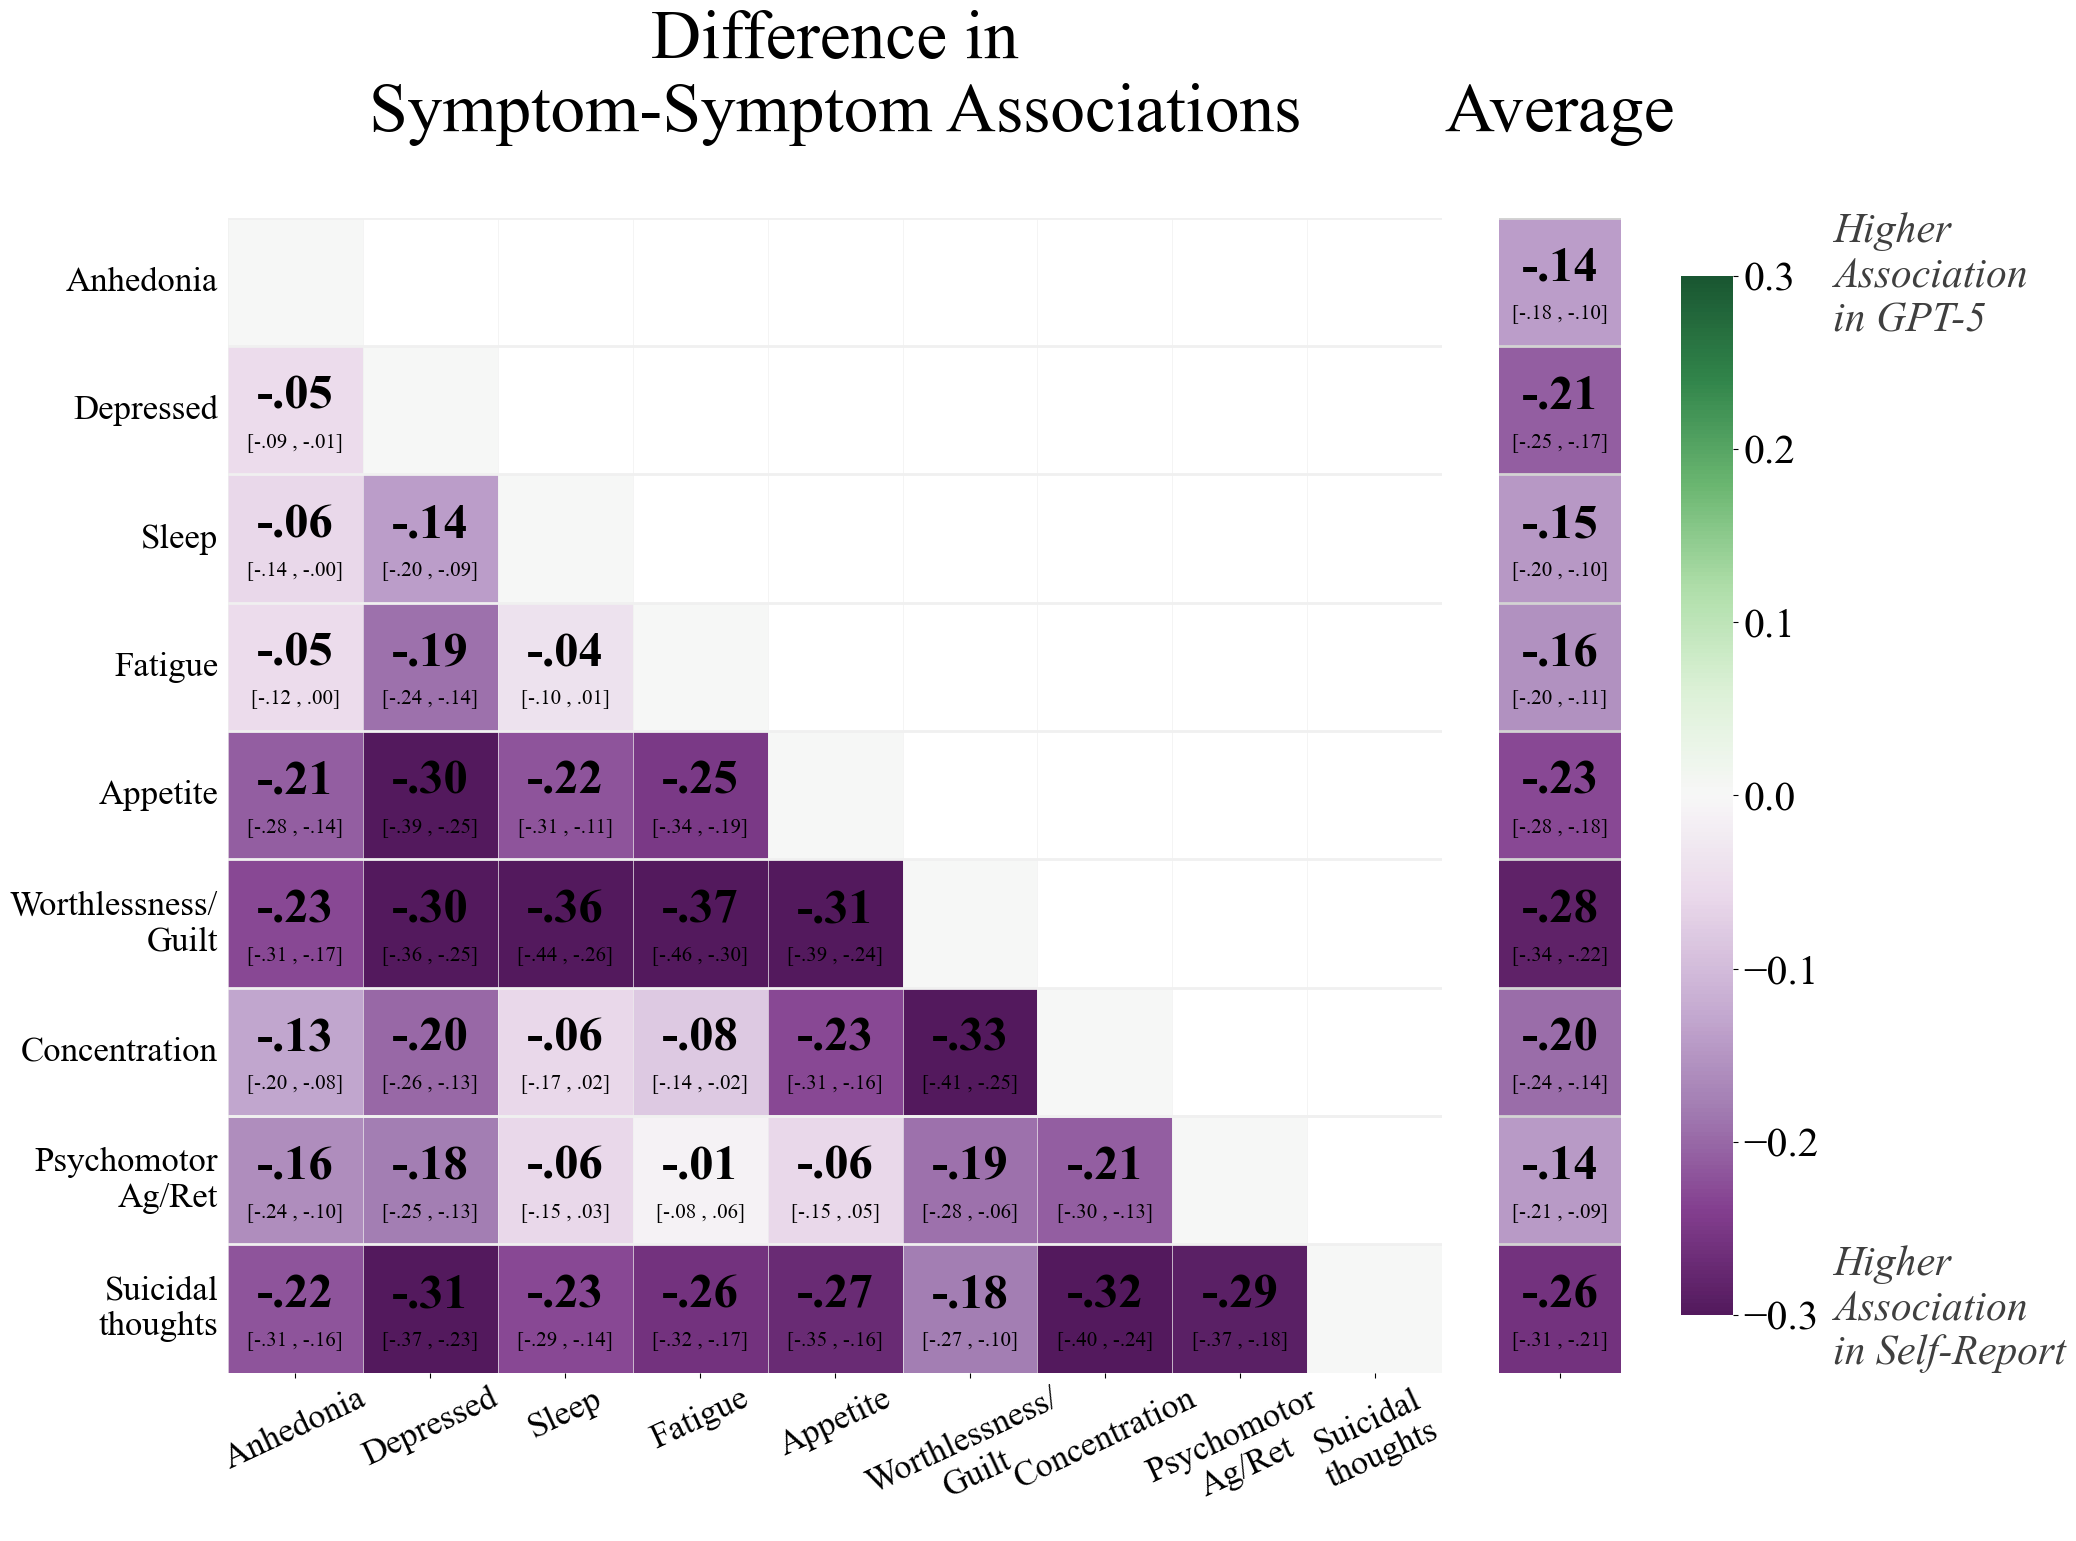

In [41]:
x_y = pd.merge(gpt5_df, self_report_df, on='user_id', suffixes=('_gpt5', '_selfreport'))
gpt5_items_corr = x_y[['{}_gpt5'.format(i) for i in score_columns]].corr()
selfreport_items_corr = x_y[['{}_selfreport'.format(i) for i in score_columns]].corr()

diff_corr = np.round(gpt5_items_corr.values - selfreport_items_corr.values, 2)
diff_corr_annot = [[f'{val:.2f}'[-3:] if val>=0 else '-'+f'{val:.2f}'[-3:] for val in row] for row in diff_corr]
for i in range(9): diff_corr_annot[i][i] = '' 

corrs_trials = []
avg_corr_trials = []
for trial in range(100):
    # sample shape[0] users with replacement
    x_y_sample = x_y.sample(n=x_y.shape[0], replace=True, random_state=trial)
    gpt5_sample_corr = x_y_sample[[f'{i}_gpt5' for i in score_columns]].corr()\
                        .rename(columns={f'{i}_gpt5':i for i in score_columns}, 
                                index={f'{i}_gpt5':i for i in score_columns})
    sr_sample_corr = x_y_sample[[f'{i}_selfreport' for i in score_columns]].corr()\
                        .rename(columns={f'{i}_selfreport':i for i in score_columns}, 
                                index={f'{i}_selfreport':i for i in score_columns})
    sample = gpt5_sample_corr - sr_sample_corr
    # calculate the correlation matrix
    diff_corr_df = sample.values.round(2)
    # append to corrs_trials
    corrs_trials.append(diff_corr_df)
    avg_sample = (diff_corr_df.sum(axis=1)/8.0).reshape(-1, 1)
    avg_corr_trials.append(avg_sample)

# create a 3D array of the correlation matrices
corrs_trials = np.array(corrs_trials)
avg_corr_trials = np.array(avg_corr_trials)
# sort along the trials axis and take the 2.5th and 97.5th percentiles
lower_bound = np.percentile(corrs_trials, 2.5, axis=0)
upper_bound = np.percentile(corrs_trials, 97.5, axis=0)
avg_lower_bound = np.percentile(avg_corr_trials, 2.5, axis=0)
avg_upper_bound = np.percentile(avg_corr_trials, 97.5, axis=0)

# annotate the corr_df_annot with [lower_bound, upper_bound] below the correlation values in smaller font
conf_bounds_annot = corr_df_annot.copy()
for idx in range(9):
    for jdx in range(9):
        if idx != jdx:
            lwr_bound_annot = f'{lower_bound[idx, jdx]:.2f}'[-3:] if lower_bound[idx, jdx]>=0 else '-'+f'{lower_bound[idx, jdx]:.2f}'[-3:]
            upr_bound_annot = f'{upper_bound[idx, jdx]:.2f}'[-3:] if upper_bound[idx, jdx]>=0 else '-'+f'{upper_bound[idx, jdx]:.2f}'[-3:]
            conf_bounds_annot.iloc[idx, jdx] = '['+lwr_bound_annot+' , '+ upr_bound_annot+']'

conf_bounds_avg_annot = []
for i in range(9):
    lower_bound_annot = f'{avg_lower_bound[i][0]:.2f}'[-3:] if avg_lower_bound[i][0]>=0 else '-'+f'{avg_lower_bound[i][0]:.2f}'[-3:]
    upper_bound_annot = f'{avg_upper_bound[i][0]:.2f}'[-3:] if avg_upper_bound[i][0]>=0 else '-'+f'{avg_upper_bound[i][0]:.2f}'[-3:]
    conf_bounds_avg_annot.append('['+lower_bound_annot+' , '+ upper_bound_annot+']')

mask = np.zeros_like(diff_corr, dtype="bool")
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False


f = plt.figure(figsize=(21, 15))
gs1 = gridspec.GridSpec(1, 2, figure=f, right=0.875, width_ratios=[0.80, 0.20], wspace=0.075)
# gs2 = gridspec.GridSpec(1, 2, figure=f, left=0.82, bottom=0.3, width_ratios=[0.5, 0.5], wspace=0.1)

a0 = f.add_subplot(gs1[0])
a1 = f.add_subplot(gs1[1])


sns.heatmap(diff_corr, annot=False, mask=mask, cmap=custom_cmap, vmin=-.3, vmax=.3, alpha=0.9, fmt='',  
            annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'black'}, 
            ax=a0, cbar=False)

# Add custom annotations
for i in range(9):
    for j in range(9):
        if not mask[i, j]:
            corr_text = f'{diff_corr_annot[i][j]}'
            conf_bounds = conf_bounds_annot.iloc[i, j]
            
            a0.text(j + 0.5, i + 0.4, corr_text, ha='center', va='center',
                    fontsize=35, fontweight='bold', color='black', fontproperties=custom_font_bold)
            if i!= j:
                a0.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
                    fontsize=15, color='black', fontproperties=custom_font)


a0.tick_params(left=False, bottom=True)

for i in range(9):
    a0.axhline(i, color='#f0f0f0', lw=2)
    a0.axvline(i, color='#f0f0f0', lw=.5)
# a0.axhline(7, color='white', lw=6)
a0.axhline(7, color='#f0f0f0', lw=2)

tick_pos = range(9)
tick_labels = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']
tick_labels_y = ['Anhedonia', 'Depressed', 'Sleep', 'Fatigue', 'Appetite', 'Worthlessness/\nGuilt', 'Concentration', 'Psychomotor\nAg/Ret', 'Suicidal\nthoughts']

a0.set_xticklabels(tick_labels, rotation=25, fontsize=25, fontproperties=custom_font)
a0.set_yticklabels(tick_labels_y, rotation=0, fontsize=25,  fontproperties=custom_font)

avgs = (diff_corr.sum(axis=1)/8.0).reshape(-1, 1)
avgs_annot = [[f'{v:.2f}'[-3:] if v>=0 else '-'+f'{v:.2f}'[-3:] for v in row] for row in avgs]

sns.heatmap(avgs, annot=False, cmap=custom_cmap, vmin=-0.3, vmax=0.3, alpha=0.9, fmt='', ax=a1, annot_kws={
                'fontsize': 35,
                'fontweight': 'bold',
                'fontproperties': custom_font_bold,
                'color': 'black'
            }, cbar_kws={'fraction': 0.4, 'shrink':0.9, 'pad': 0.2}, cbar=True)

for i in range(9):
    corr_text = avgs_annot[i][0]
    conf_bounds = conf_bounds_avg_annot[i]
    a1.text(0.5, i + 0.4, corr_text, ha='center', va='center',
            fontsize=35, fontweight='bold', color='black', fontproperties=custom_font_bold)
    a1.text(0.5, i + 0.75, conf_bounds, ha='center', va='center',
            fontsize=15, color='black', fontproperties=custom_font)
    a1.axhline(i, color='lightgray', lw=2)
# a1.axhline(7, color='white', lw=6)

a1.set_yticklabels([], rotation=0, fontsize=27,  fontproperties=custom_font)
a1.yaxis.tick_right()
a1.tick_params(right=False, bottom=True, left=False)
a1.set_xticklabels([''], rotation=0, fontsize=35,  fontproperties=custom_font)

cbar = a1.collections[0].colorbar
# Apply font properties to the colorbar's tick labels
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(custom_font)
# here set the labelsize by 20
cbar.ax.tick_params(labelsize=30)

a1.text(2.75, 0.45, 'Higher\nAssociation\nin GPT-5', ha='left', va='center', fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')
a1.text(2.75, 8.5, 'Higher\nAssociation\nin Self-Report', ha='left', va='center', fontsize=30, fontproperties=custom_font_italics, color='#3f3f3f')

# # Add ghost axes and titles on gs1 and gs2
# ax_left = f.add_subplot(gs1[:])
# ax_left.axis('off')
a0.set_title('Difference in\nSymptom-Symptom Associations\n', fontsize=50, fontproperties=custom_font)

# ax_right = f.add_subplot(gs2[:])
# ax_right.axis('off')
a1.set_title('Average\n', fontsize=50, fontproperties=custom_font)



# plt.savefig('../data/figures/diff_gpt4_sr_corr_triu.png', dpi=1040, bbox_inches='tight')
plt.savefig('../data/figures/diff_gpt5_sr_corr_triu.pdf', dpi=1040, bbox_inches='tight')
plt.show()
# save figure


## IRT

In [16]:
import pickle5 as pickle
from scipy import stats
import numpy as np
import pandas as pd

PATH_TO_JSON = '/cronus_data/avirinchipur/reasoning_for_psych/irt/gpt5_sr_fulldata_ranking.pkl'
combined_data_symp_rank = pickle.load(open(PATH_TO_JSON, 'rb'))

In [17]:
combined_data_symp_rank['gpt5'].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [18]:
gpt5_symp_ranks_all = []
self_symp_ranks_all = []
for i in range(9):
    gpt5_symp_ranks_all.append(np.array(combined_data_symp_rank['gpt5'][i]))
    self_symp_ranks_all.append(np.array(combined_data_symp_rank['self_report'][i]))

gpt5_symp_ranks_all = np.array(gpt5_symp_ranks_all)
self_symp_ranks_all = np.array(self_symp_ranks_all)

print ("Shapes: ", gpt5_symp_ranks_all.shape, self_symp_ranks_all.shape)

spearman_corr = []
kendall_corr = []
for i in range(gpt5_symp_ranks_all.shape[1]):
    spearman_corr.append(stats.spearmanr(gpt5_symp_ranks_all[:,i], self_symp_ranks_all[:,i]))
    kendall_corr.append(stats.kendalltau(gpt5_symp_ranks_all[:,i], self_symp_ranks_all[:,i]))
    
# Report the 95% confidence interval of the Spearman correlation
spearman_corr = np.array(spearman_corr)[:, 0]
kendall_corr = np.array(kendall_corr)[:, 0]
print (f"95% confidence interval of Spearman correlation: {np.percentile(spearman_corr, 5).round(3)} - {np.percentile(spearman_corr, 95).round(3)}")
print (f"95% confidence interval of Kendall correlation: {np.percentile(kendall_corr, 5).round(3)} - {np.percentile(kendall_corr, 95).round(3)}")


Shapes:  (9, 500) (9, 500)
95% confidence interval of Spearman correlation: 0.817 - 0.9
95% confidence interval of Kendall correlation: 0.556 - 0.778


In [19]:
colnames = ['score_Anhedonia', 'score_Depressed_Mood', 'score_Insomnia_or_Hypersomnia', 'score_Fatigue', \
        'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt', 'score_Difficulty_concentrating', \
        'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

In [26]:
# Compute 95% confidence interval of the ranks of each symptom 
rank_bounds = {}
for i in range(9):
    gpt5_rank = gpt5_symp_ranks_all[i]
    self_rank = self_symp_ranks_all[i]
    gpt5_rank_stderr = (np.std(gpt5_rank) / np.sqrt(len(gpt5_rank))).round(2)
    self_rank_stderr = (np.std(self_rank) / np.sqrt(len(self_rank))).round(2)
    rank_bounds[colnames[i]] = [np.percentile(gpt5_rank, 2.5), np.percentile(gpt5_rank, 97.5), #gpt5_rank_stderr, 
                                np.percentile(self_rank, 2.5), np.percentile(self_rank, 97.5)#, self_rank_stderr
                                ]

10-pd.DataFrame(rank_bounds, index=['gpt5_upr', 'gpt5_lwr', 'Self_upr', 'Self_lwr']).T

,gpt5_upr,gpt5_lwr,Self_upr,Self_lwr
score_Anhedonia,2.000,2.0,3.0,3.0
score_Depressed_Mood,1.000,1.0,2.0,1.0
score_Insomnia_or_Hypersomnia,6.000,4.0,6.0,4.0
score_Fatigue,3.000,3.0,2.0,1.0
score_Poor_appetite_or_overeating,9.000,8.0,7.0,7.0
score_Worthlessness_or_Guilt,6.000,4.0,6.0,4.0
score_Difficulty_concentrating,6.000,4.0,6.0,4.0
score_Psychomotor_agitation_or_retardation,9.000,8.0,8.0,8.0
score_Suicidal_ideation,7.525,7.0,9.0,9.0


In [30]:
fulldata_ranks = pd.read_csv('/cronus_data/avirinchipur/reasoning_for_psych/irt/gpt5_sr_fulldata_ranking.csv')
fulldata_ranks

,gpt5,self_report,columns
0,8.0,7.0,score_Anhedonia
1,9.0,8.0,score_Depressed_Mood
2,4.0,6.0,score_Insomnia_or_Hypersomnia
3,7.0,9.0,score_Fatigue
4,1.0,3.0,score_Poor_appetite_or_overeating
5,6.0,5.0,score_Worthlessness_or_Guilt
6,5.0,4.0,score_Difficulty_concentrating
7,2.0,2.0,score_Psychomotor_agitation_or_retardation
8,3.0,1.0,score_Suicidal_ideation


In [34]:
10-fulldata_ranks.set_index('columns').astype(int)

,gpt5,self_report
columns,,
score_Anhedonia,2,3
score_Depressed_Mood,1,2
score_Insomnia_or_Hypersomnia,6,4
score_Fatigue,3,1
score_Poor_appetite_or_overeating,9,7
score_Worthlessness_or_Guilt,4,5
score_Difficulty_concentrating,5,6
score_Psychomotor_agitation_or_retardation,8,8
score_Suicidal_ideation,7,9


## Explicit and Implicit Items

In [48]:
symptoms_columns = ['Anhedonia', 'Depressed_Mood', 'Insomnia_or_Hypersomnia',
       'Fatigue', 'Poor_appetite_or_overeating', 'Worthlessness_or_Guilt',
       'Difficulty_concentrating', 'Psychomotor_agitation_or_retardation',
       'Suicidal_ideation']
       
score_columns = ['score_Anhedonia', 'score_Depressed_Mood',
       'score_Insomnia_or_Hypersomnia', 'score_Fatigue',
       'score_Poor_appetite_or_overeating', 'score_Worthlessness_or_Guilt',
       'score_Difficulty_concentrating',
       'score_Psychomotor_agitation_or_retardation', 'score_Suicidal_ideation']

isInferred_columns = ['isInferred_Anhedonia', 'isInferred_Depressed_Mood',
         'isInferred_Insomnia_or_Hypersomnia', 'isInferred_Fatigue',
         'isInferred_Poor_appetite_or_overeating',
         'isInferred_Worthlessness_or_Guilt',
         'isInferred_Difficulty_concentrating',
         'isInferred_Psychomotor_agitation_or_retardation',
         'isInferred_Suicidal_ideation']

spans_columns = ['spans_Anhedonia', 'spans_Depressed_Mood',
       'spans_Insomnia_or_Hypersomnia', 'spans_Fatigue',
       'spans_Poor_appetite_or_overeating', 'spans_Worthlessness_or_Guilt',
       'spans_Difficulty_concentrating',
       'spans_Psychomotor_agitation_or_retardation', 'spans_Suicidal_ideation']

In [49]:
# Caluclate the correlation between gpt4 and self report for each symptom under two conditions, 
# 1. considering only the explicit occurences
# 2. considering only implicit occurences

gpt5_sr_exp_imp_pearsonr = []
for symptom in symptoms_columns:
    exp_rows = gpt5_df[gpt5_df['isInferred_'+symptom] == 0].user_id.tolist()
    imp_rows = gpt5_df[gpt5_df['isInferred_'+symptom] == 1].user_id.tolist()
    symptom_scores = 'score_' + symptom
    gpt5_sr_merge_exp = gpt5_df[gpt5_df['user_id'].isin(exp_rows)][['user_id', symptom_scores]].merge(self_report_df[['user_id', symptom_scores]], on='user_id')
    gpt5_sr_merge_imp = gpt5_df[gpt5_df['user_id'].isin(imp_rows)][['user_id', symptom_scores]].merge(self_report_df[['user_id', symptom_scores]], on='user_id')
    exp_pearsonr, _ = pearsonr(gpt5_sr_merge_exp[symptom_scores+'_x'], gpt5_sr_merge_exp[symptom_scores+'_y'])
    imp_pearsonr, _ = pearsonr(gpt5_sr_merge_imp[symptom_scores+'_x'], gpt5_sr_merge_imp[symptom_scores+'_y'])
    temp = [symptom, round(100*len(exp_rows)/gpt5_df.shape[0], 2), round(exp_pearsonr, 2), round(100*len(imp_rows)/gpt5_df.shape[0], 2), round(imp_pearsonr, 2)]
    gpt5_sr_exp_imp_pearsonr.append(temp)

pd.DataFrame(gpt5_sr_exp_imp_pearsonr, columns=['symptom', 'explicit %', 'explicit_pearsonr', 'implicit %', 'implicit_pearsonr'])    

,symptom,explicit %,explicit_pearsonr,implicit %,implicit_pearsonr
0,Anhedonia,41.21,0.72,58.79,0.52
1,Depressed_Mood,88.81,0.74,11.19,0.51
2,Insomnia_or_Hypersomnia,12.45,0.53,87.55,0.35
3,Fatigue,17.36,0.57,82.64,0.40
4,Poor_appetite_or_overeating,5.65,0.70,94.35,0.20
5,Worthlessness_or_Guilt,19.56,0.56,80.44,0.28
6,Difficulty_concentrating,11.82,0.46,88.18,0.31
7,Psychomotor_agitation_or_retardation,4.60,0.04,95.40,0.11
8,Suicidal_ideation,12.97,0.70,87.03,0.05


## Training models to understand the effect explicit scores on implicit symptoms

In [51]:
from sklearn.linear_model import LinearRegression

In [50]:
def get_symptom_scores(df:pd.DataFrame, imp_symptom:str, infill=None):
    exp_columns = symptoms_columns.copy()
    exp_columns.remove(imp_symptom)
    exp_columns_isInferred = ['isInferred_'+symptom for symptom in exp_columns]
    exp_columns_score = ['score_'+ symptom for symptom in exp_columns]
    y = df[df['isInferred_'+imp_symptom]==1]['score_'+imp_symptom]
    X = df[df['isInferred_'+imp_symptom]==1][exp_columns_score]
    z = df[df['isInferred_'+imp_symptom]==1][exp_columns_isInferred]
    
    if infill == 'zero':
        # for each column, turn the rows that had implicit mention of symptoms in X to  0
        for column in exp_columns: X.loc[z['isInferred_'+column]==1, 'score_'+column] = 0
    elif infill == 'mean':
        # for each column, turn the rows that had implicit mention of symptoms in X to mean of the column when it was explicit
        for column in exp_columns:
            mean_val = X.loc[z['isInferred_'+column]==0, 'score_'+column].mean()
            if np.isnan(mean_val): mean_val = 0
            X.loc[z['isInferred_'+column]==1, 'score_'+column] = mean_val
    
    return X, y, exp_columns    

In [52]:
# Infill strategy is mean
multivariate_coef2 = {}
for column in symptoms_columns:
    X, y, cols = get_symptom_scores(gpt5_df, column, infill='mean')
    # lr = LinearRegression(positive=True)
    lr = LinearRegression()
    lr.fit(X, y)
    multivariate_coef2[column] = dict(zip(cols, lr.coef_))
    # multivariate_coef2[column]['n'] = (len(X))
    
multivariate_coef2 = pd.DataFrame(multivariate_coef2).round(2)
multivariate_coef2 = multivariate_coef2.loc[symptoms_columns]

In [54]:
# Infill strategy is mean, run the statistics for 100 trials and report avg coef. Store the std dev as well
multivariate_coef2_trials = {}
num_trials = 500
for trial_num in range(num_trials):
    df = gpt5_df.sample(frac=1, replace=True, random_state=trial_num)
    for column in symptoms_columns:
        X, y, cols = get_symptom_scores(df, column, infill='mean')
        lr = LinearRegression(positive=False)
        lr.fit(X, y)
        if column not in multivariate_coef2_trials:
            multivariate_coef2_trials[column] = []
        multivariate_coef2_trials[column].append(dict(zip(cols, lr.coef_)))

In [55]:
multivariate_coef2_avg = {}
multivariate_coef2_std = {}
multivariate_coef2_med = {}

for column in symptoms_columns:
    multivariate_coef2_avg[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.mean(axis=1)
    multivariate_coef2_std[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.std(axis=1)/np.sqrt(num_trials)
    multivariate_coef2_med[column] = pd.DataFrame(multivariate_coef2_trials[column]).T.median(axis=1)

multivariate_coef2_avg = pd.DataFrame(multivariate_coef2_avg).loc[symptoms_columns]
multivariate_coef2_std = pd.DataFrame(multivariate_coef2_std).loc[symptoms_columns]
multivariate_coef2_med = pd.DataFrame(multivariate_coef2_med).loc[symptoms_columns]

In [56]:
# Calculate the 90% confidence interval for the coefficients from multivariate_coef2
multivariate_coef2_ci = []
for idx, symptom in enumerate(symptoms_columns):
    coef_df = pd.DataFrame(multivariate_coef2_trials[symptom])
    coef_df = coef_df.T
    temp_df = coef_df.quantile([0.05, 0.95], axis=1).reset_index(drop=True).T.apply(lambda x: [round(x[0], 2), round(x[1], 2)], axis=1)
    temp_df = pd.DataFrame(temp_df, columns=[symptom]) 
    multivariate_coef2_ci.append(temp_df)
multivariate_coef2_ci = pd.concat(multivariate_coef2_ci, axis=1).loc[symptoms_columns]

Text(0.5, 1.0, 'Median Coefficients for 500 trials with 90% CI\n')

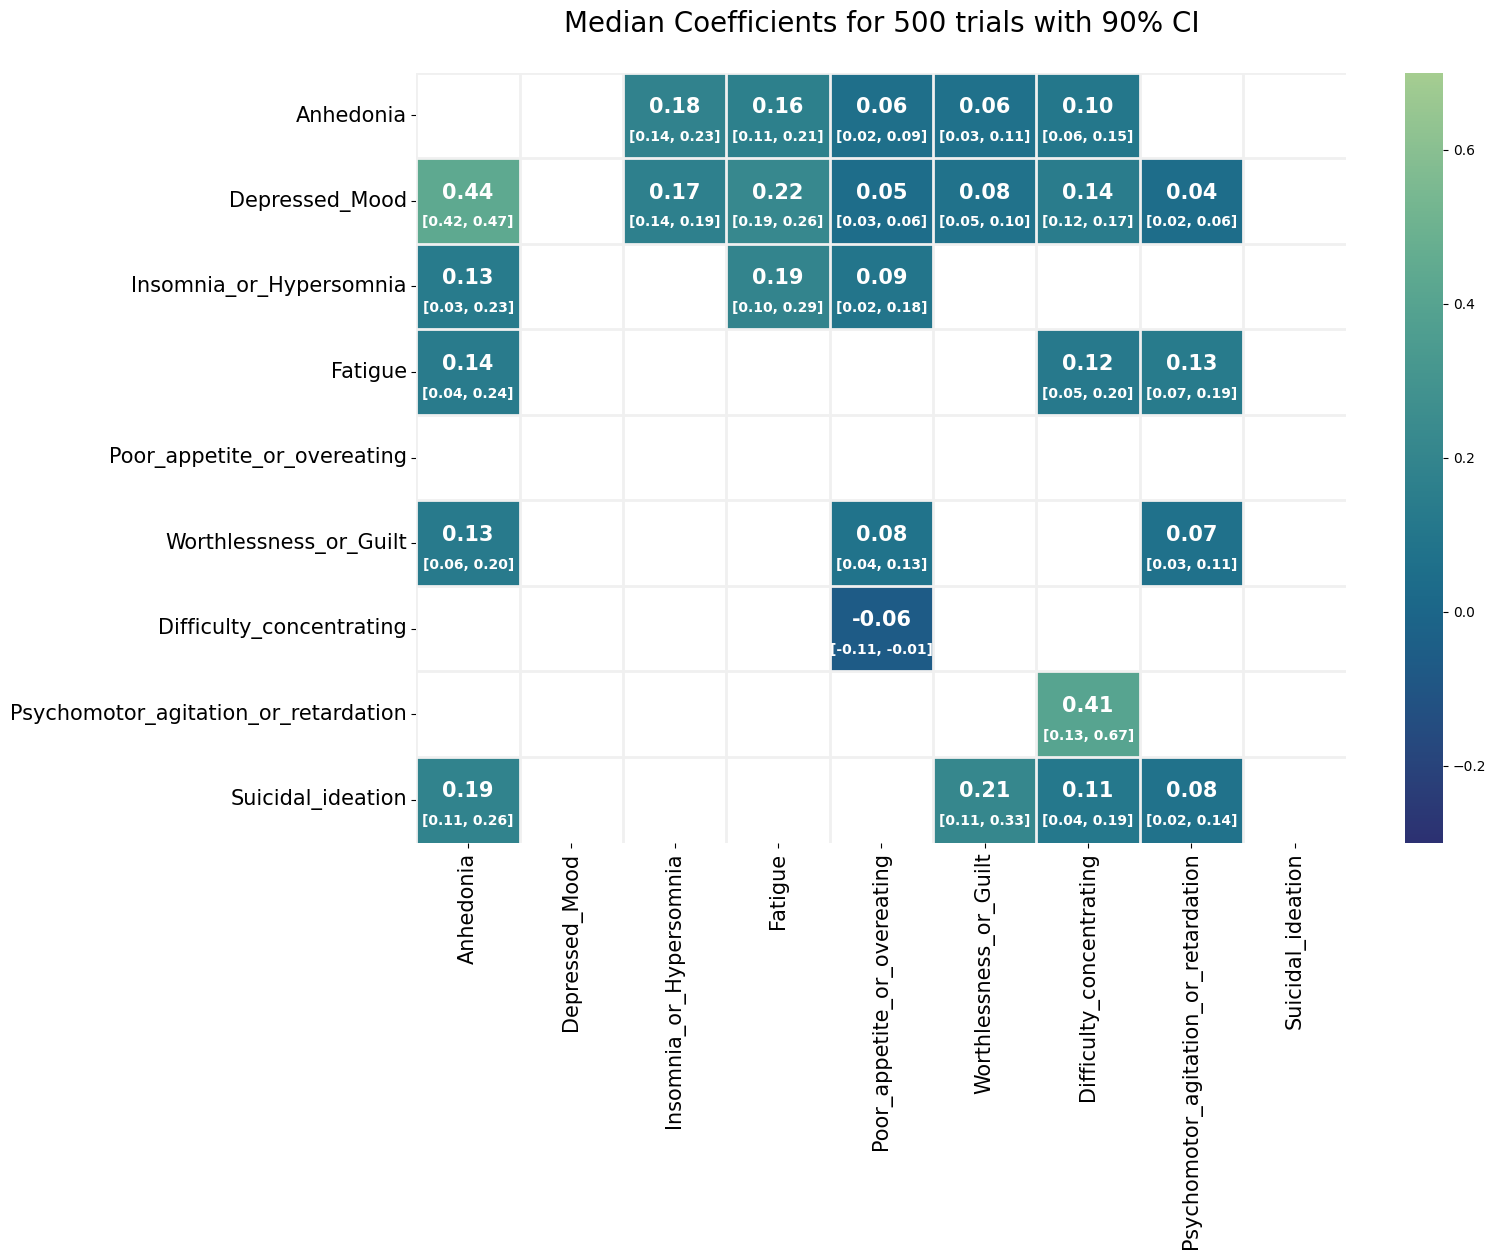

In [57]:
# multivariate_coef2_avg
fig, ax = plt.subplots(figsize=(15, 10))
mask = np.zeros_like(multivariate_coef2_med)
for idx in range(mask.shape[0]):
    for jdx in range(mask.shape[1]):
        # if (idx != jdx) and np.abs(multivariate_coef2_med.iloc[idx, jdx]) <= 0.1:
        if (idx == jdx) or (multivariate_coef2_ci.iloc[idx, jdx][0] <= 0 and multivariate_coef2_ci.iloc[idx, jdx][1] >= 0):
            mask[idx, jdx] = True

mask = mask.astype(bool)             
sns.heatmap(multivariate_coef2_med, annot=False, cmap='crest_r', fmt='', vmin=-0.3, vmax=0.7, mask=mask)

for i, col_i in enumerate(symptoms_columns):
    for j, col_j in enumerate(symptoms_columns):
        if mask[i, j] == False:
            corr_text = "{:0.2f}".format(multivariate_coef2_med.loc[col_i, col_j])
            # conf_bounds = str(multivariate_coef2_std.loc[col_i, col_j])
            conf_bounds = "[{:0.2f}, {:0.2f}]".format(multivariate_coef2_ci.loc[col_i, col_j][0], multivariate_coef2_ci.loc[col_i, col_j][1])
            # conf_bounds = str([multivariate_coef2_ci.loc[col_i, col_j][0].round(2), multivariate_coef2_ci.loc[col_i, col_j][1].round(2)])
              
            ax.text(j + 0.5, i + 0.4, corr_text, ha='center', va='center',
                    fontsize=15, fontweight='bold', color='white')
            ax.text(j + 0.5, i + 0.75, conf_bounds, ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')

ax.set_xticklabels(symptoms_columns, fontsize=15)
ax.set_yticklabels(symptoms_columns, fontsize=15)     

for i in range(9):
    ax.axhline(i, color='#f0f0f0', lw=2)
    ax.axvline(i, color='#f0f0f0', lw=2)

# ax.set_title('Median Coefficients for 500 trials with 90% CI\n(Constrainted)', fontsize=20)
ax.set_title('Median Coefficients for 500 trials with 90% CI\n', fontsize=20)

In [58]:
symptoms_to_sankey = {"Anhedonia": "Anhedonia", "Depressed_Mood": "Depressed", 
                      "Insomnia_or_Hypersomnia": "Sleep", "Fatigue": "Fatigue",
                      "Poor_appetite_or_overeating": "Appetite", "Worthlessness_or_Guilt": "Worthlessness",
                      "Difficulty_concentrating": "Concentration", "Psychomotor_agitation_or_retardation": "Psychomotor",
                      "Suicidal_ideation": "Suicidal"}

for idx, symptom_exp in enumerate(multivariate_coef2_med.index):
    for jdx, symptom_imp in enumerate(multivariate_coef2_med.columns):
        if mask[idx, jdx]: continue
        print ("{}_exp [{:0.2f}] {}_imp".format(symptoms_to_sankey[symptom_exp], multivariate_coef2_med.iloc[idx, jdx].round(2), symptoms_to_sankey[symptom_imp]))
    print ()

Anhedonia_exp [0.18] Sleep_imp
Anhedonia_exp [0.16] Fatigue_imp
Anhedonia_exp [0.06] Appetite_imp
Anhedonia_exp [0.06] Worthlessness_imp
Anhedonia_exp [0.10] Concentration_imp

Depressed_exp [0.44] Anhedonia_imp
Depressed_exp [0.17] Sleep_imp
Depressed_exp [0.22] Fatigue_imp
Depressed_exp [0.05] Appetite_imp
Depressed_exp [0.08] Worthlessness_imp
Depressed_exp [0.14] Concentration_imp
Depressed_exp [0.04] Psychomotor_imp

Sleep_exp [0.13] Anhedonia_imp
Sleep_exp [0.19] Fatigue_imp
Sleep_exp [0.09] Appetite_imp

Fatigue_exp [0.14] Anhedonia_imp
Fatigue_exp [0.12] Concentration_imp
Fatigue_exp [0.13] Psychomotor_imp


Worthlessness_exp [0.13] Anhedonia_imp
Worthlessness_exp [0.08] Appetite_imp
Worthlessness_exp [0.07] Psychomotor_imp

Concentration_exp [-0.06] Appetite_imp

Psychomotor_exp [0.41] Concentration_imp

Suicidal_exp [0.19] Anhedonia_imp
Suicidal_exp [0.21] Worthlessness_imp
Suicidal_exp [0.11] Concentration_imp
Suicidal_exp [0.08] Psychomotor_imp

